In [89]:
# !pip install -q segmentation-models-pytorch

# COVID Segmentation

**Autores:**

- Jorge Armando Garzón Varela - A01707102
- Santiago Alducin Villaseñor - A01707122
- Sebastián Pérez García - A01707346
- Kamila Jeannette Martínez Ibarra - A01711833

---

## 1. Introducción

Proporcionen una descripción clara y concisa del problema que están resolviendo.
Expliquen los objetivos de la competencia y la relevancia de las tareas de segmentación en imágenes médicas para el COVID-19.
Mencionen el notebook de inicio original sobre el que están desarrollando su solución y expliquen cómo su enfoque mejora o amplía el trabajo anterior.

#### Imports y configuración

In [90]:
import os
from dataclasses import dataclass
from pathlib import Path

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import ndimage

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

In [91]:
PROJECT_ROOT = Path.cwd()
DATA_PREFIX = PROJECT_ROOT
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 2
IMAGE_HEIGHT = 160
IMAGE_WIDTH = 240
BATCH_SIZE = 32
RUN_HYPERPARAMETER_SEARCH = False
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

---

## 2. Datos

Exploración de datos: Describan el conjunto de datos proporcionado en la competencia. Esto debe incluir el número de muestras, dimensiones de las imágenes y las clases. Visualicen algunos ejemplos de las imágenes y las máscaras de segmentación correspondientes.
Preprocesamiento de datos: Expliquen los pasos de preprocesamiento que realizaron, como el cambio de tamaño, normalización, aumento de datos, etc.
Análisis de datos: Realicen cualquier análisis estadístico o visual significativo del conjunto de datos que pueda influir en sus decisiones de modelado, como desequilibrios de clases o peculiaridades en los datos.

### 2.1 Exploración de Datos

#### Carga de Datos

In [92]:
def load_data(prefix=DATA_PREFIX):
    """Carga los .npy de imágenes y máscaras (radiopedia + medseg)."""
    data = {
      'images_radiopedia': np.load(prefix / 'images_radiopedia.npy').astype(np.float32),
      'masks_radiopedia': np.load(prefix / 'masks_radiopedia.npy').astype(np.int8),
      'images_medseg': np.load(prefix / 'images_medseg.npy').astype(np.float32),
      'masks_medseg': np.load(prefix / 'masks_medseg.npy').astype(np.int8),
      'test_images_medseg': np.load(prefix / 'test_images_medseg.npy').astype(np.float32),
    }
    return data

In [93]:
data = load_data(DATA_PREFIX)

print("Datasets cargados:")
for key, value in data.items():
    print(f"{key}: shape={value.shape}, dtype={value.dtype}")

Datasets cargados:
images_radiopedia: shape=(829, 512, 512, 1), dtype=float32
masks_radiopedia: shape=(829, 512, 512, 4), dtype=int8
images_medseg: shape=(100, 512, 512, 1), dtype=float32
masks_medseg: shape=(100, 512, 512, 4), dtype=int8
test_images_medseg: shape=(10, 512, 512, 1), dtype=float32


#### Verificación de Integridad

In [94]:
def check_integrity(images, masks, name):
    """Verifica cantidad de muestras y dimensiones espaciales."""
    assert len(images) == len(masks), (f"{name}: cantidad de imágenes y máscaras no coincide ({len(images)} vs {len(masks)})")
    assert images.shape[1:3] == masks.shape[1:3], (f"{name}: dimensiones espaciales no coinciden")

    print(f"{name}: OK | " f"{len(images)} muestras | " f"resolución {images.shape[1:3]}")

In [95]:
check_integrity(data["images_radiopedia"], data["masks_radiopedia"], "Radiopedia")

Radiopedia: OK | 829 muestras | resolución (512, 512)


In [96]:
check_integrity(data["images_medseg"], data["masks_medseg"], "MedSeg")

MedSeg: OK | 100 muestras | resolución (512, 512)


#### Valores de las Máscaras

In [97]:
print("Radiopedia mask values:")
print(np.unique(data["masks_radiopedia"]))
print()
print("MedSeg mask values:")
print(np.unique(data["masks_medseg"]))

Radiopedia mask values:
[0 1]

MedSeg mask values:
[0 1]


In [98]:
print("Radiopedia masks:", data["masks_radiopedia"].shape)
print("MedSeg masks:", data["masks_medseg"].shape)

Radiopedia masks: (829, 512, 512, 4)
MedSeg masks: (100, 512, 512, 4)


In [99]:
masks_radiopedia = data["masks_radiopedia"]

if masks_radiopedia.ndim == 4:
    for class_idx in range(masks_radiopedia.shape[-1]):
        print(f"Class {class_idx}:", np.unique(masks_radiopedia[..., class_idx]))

Class 0: [0 1]
Class 1: [0 1]
Class 2: [0 1]
Class 3: [0 1]


In [100]:
masks_medseg = data["masks_medseg"]

if masks_medseg.ndim == 4:
    for class_idx in range(masks_medseg.shape[-1]):
        print(f"Class {class_idx}:", np.unique(masks_medseg[..., class_idx]))

Class 0: [0 1]
Class 1: [0 1]
Class 2: [0 1]
Class 3: [0 1]


#### Resumen de los Datos

In [101]:
def summarize_dataset(images, masks, name):
    print(f"--- {name} ---")
    print(f"Images shape: {images.shape}")
    print(f"Images dtype: {images.dtype}")
    print(f"Images min: {images.min():.3f}")
    print(f"Images max: {images.max():.3f}")
    print()
    print(f"Masks shape: {masks.shape}")
    print(f"Masks dtype: {masks.dtype}")
    print(f"Masks min: {masks.min():.3f}")
    print(f"Masks max: {masks.max():.3f}")

In [102]:
summarize_dataset(data["images_radiopedia"], data["masks_radiopedia"], "Radiopedia")

--- Radiopedia ---
Images shape: (829, 512, 512, 1)
Images dtype: float32
Images min: -1414.765
Images max: 291.041

Masks shape: (829, 512, 512, 4)
Masks dtype: int8
Masks min: 0.000
Masks max: 1.000


In [103]:
summarize_dataset(data["images_medseg"], data["masks_medseg"], "MedSeg")

--- MedSeg ---
Images shape: (100, 512, 512, 1)
Images dtype: float32
Images min: -1606.522
Images max: 597.805

Masks shape: (100, 512, 512, 4)
Masks dtype: int8
Masks min: 0.000
Masks max: 1.000


#### Visualización de los Datos

In [104]:
def visualize(image_batch, mask_batch=None, pred_batch=None, num_samples=8, hot_encode=True):
    num_classes = mask_batch.shape[-1] if mask_batch is not None else 0
    fig, ax = plt.subplots(num_classes + 1, num_samples, figsize=(num_samples * 2, (num_classes + 1) * 2))
    for i in range(num_samples):
        ax_image = ax[0, i] if num_classes > 0 else ax[i]
        if hot_encode:
            ax_image.imshow(image_batch[i, :, :, 0], cmap='Greys')
        else:
            ax_image.imshow(image_batch[i, :, :])
        ax_image.set_xticks([])
        ax_image.set_yticks([])

        if mask_batch is not None:
            for j in range(num_classes):
                if pred_batch is None:
                    mask_to_show = mask_batch[i, :, :, j]
                else:
                    mask_to_show = np.zeros(shape=(*mask_batch.shape[1:-1], 3))
                    mask_to_show[..., 0] = pred_batch[i, :, :, j] > 0.5
                    mask_to_show[..., 1] = mask_batch[i, :, :, j]
                ax[j + 1, i].imshow(mask_to_show, vmin=0, vmax=1)
                ax[j + 1, i].set_xticks([])
                ax[j + 1, i].set_yticks([])
    plt.tight_layout()
    plt.show()

Visualizando ejemplos de Radiopedia:


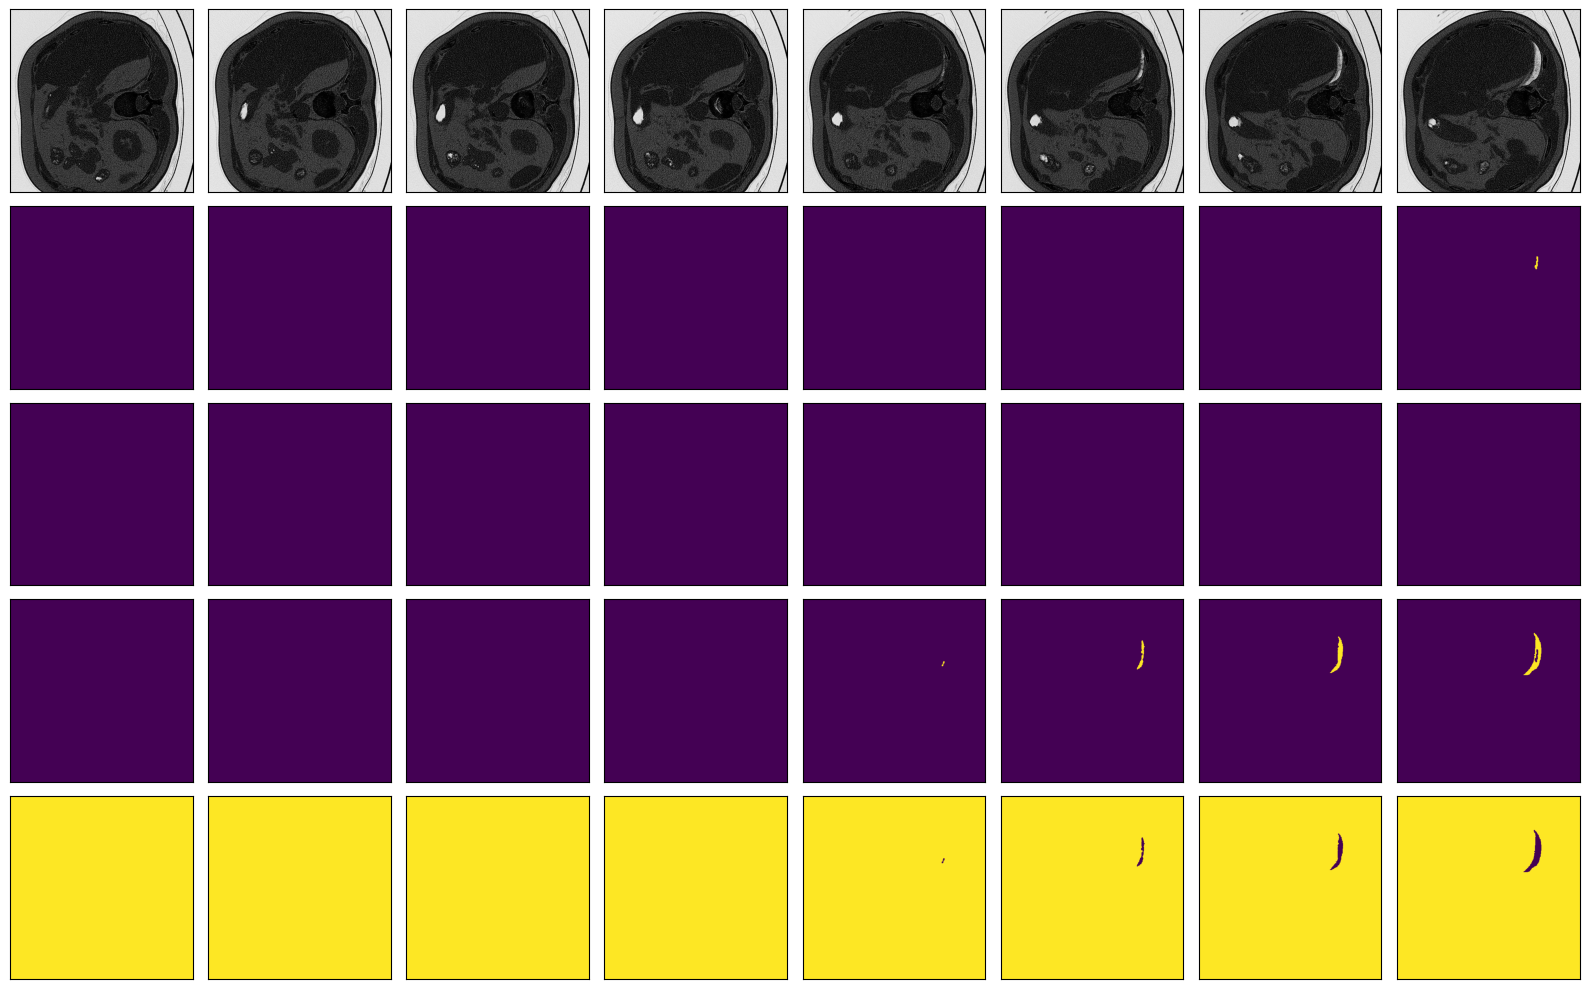

In [105]:
print("Visualizando ejemplos de Radiopedia:")
visualize(data["images_radiopedia"][:8], data["masks_radiopedia"][:8], num_samples=8, hot_encode=True)

Visualizando ejemplos de MedSeg:


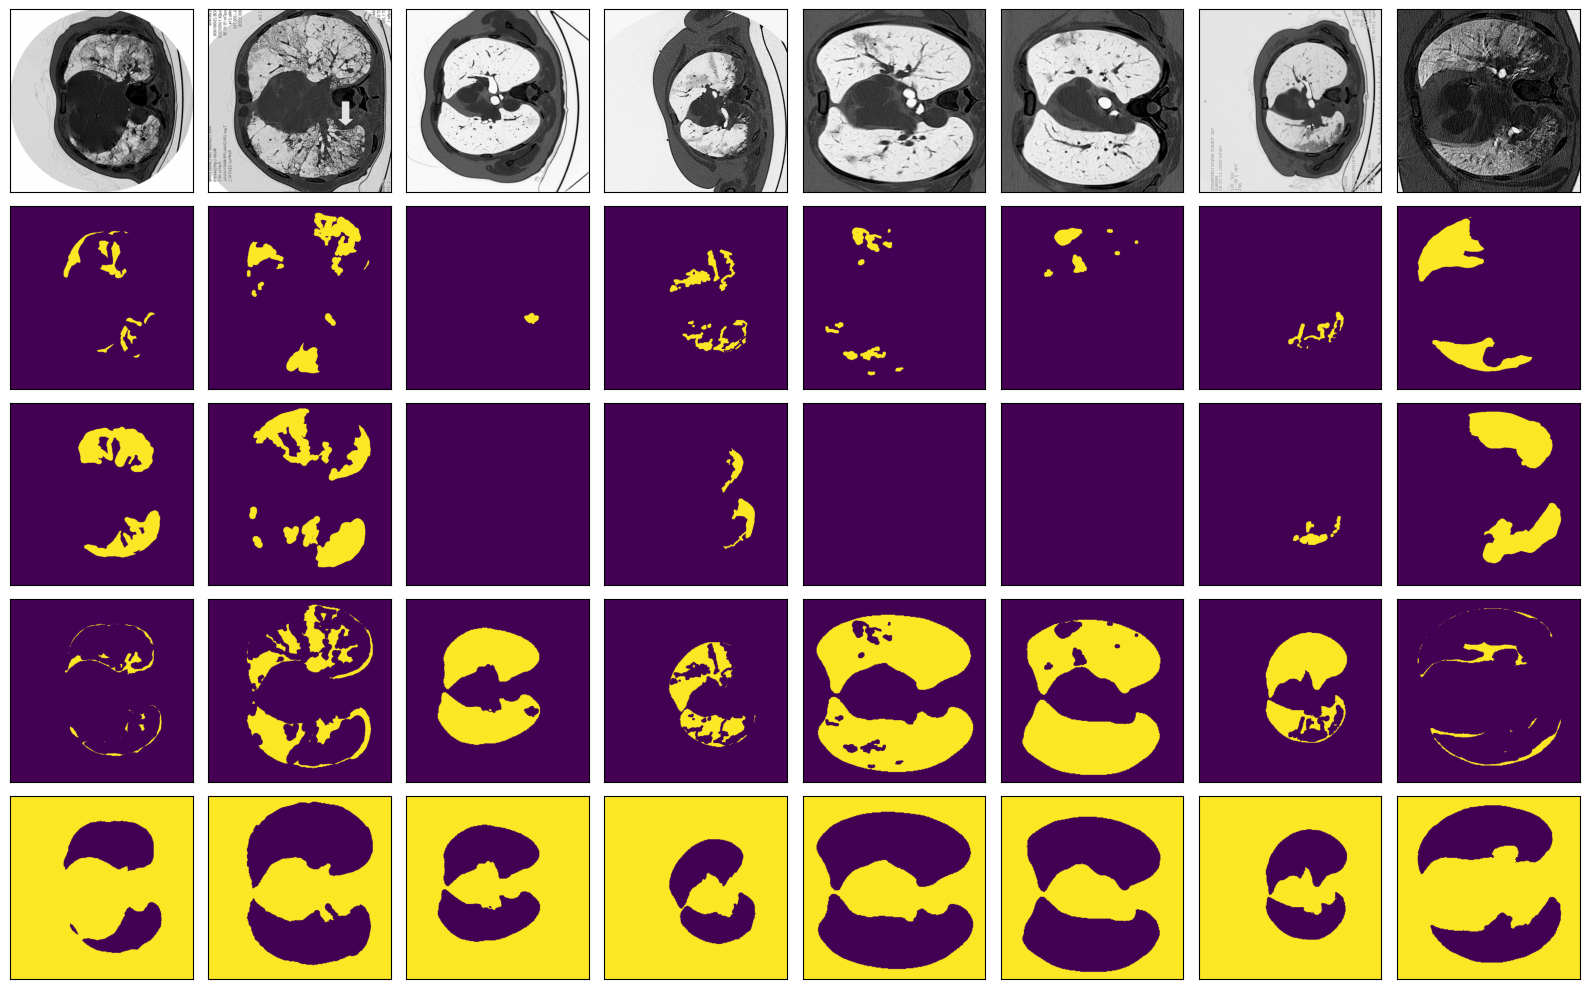

In [106]:
print("Visualizando ejemplos de MedSeg:")
visualize(data["images_medseg"][:8], data["masks_medseg"][:8], num_samples=8, hot_encode=True)

### 2.2 Análisis de Datos

#### Distribución de Clases

In [107]:
def plot_class_distribution(masks, class_names):
    pixel_counts = masks.sum(axis=(0, 1, 2))
    total_pixels = pixel_counts.sum()
    proportions = pixel_counts / total_pixels

    plt.figure(figsize=(8, 4))
    plt.bar(class_names, proportions)
    plt.xlabel("Class")
    plt.ylabel("Proportion of pixels")
    plt.title("Class distribution")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    for name, count, proportion in zip(class_names, pixel_counts, proportions):
        print(f"{name}: {count:,.0f} pixels ({proportion:.4%})")

    return proportions

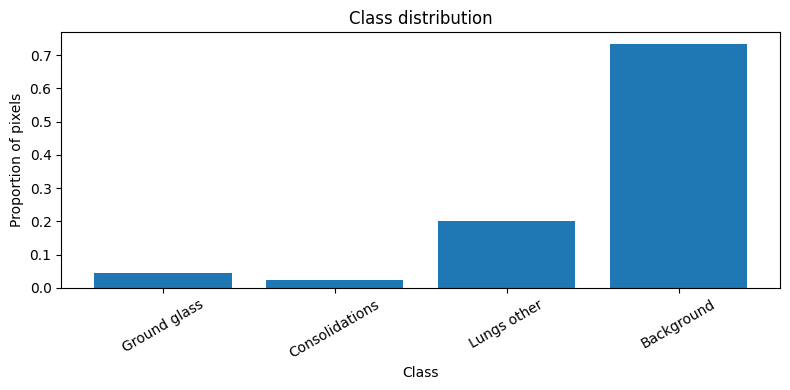

Ground glass: 1,196,461 pixels (4.5640%)
Consolidations: 589,210 pixels (2.2476%)
Lungs other: 5,239,132 pixels (19.9853%)
Background: 19,190,107 pixels (73.2030%)


In [108]:
class_names = ["Ground glass", "Consolidations", "Lungs other", "Background"]
target_class_names = ["Ground glass", "Consolidations"]

train_class_proportions = plot_class_distribution(data["masks_medseg"], class_names)

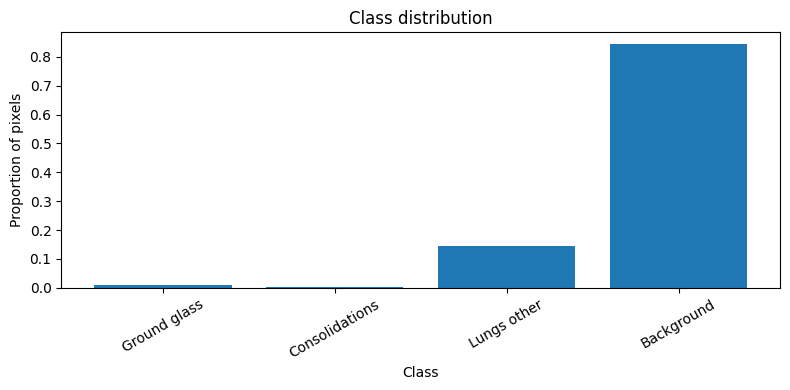

Ground glass: 2,219,009 pixels (1.0210%)
Consolidations: 496,252 pixels (0.2283%)
Lungs other: 31,506,104 pixels (14.4963%)
Background: 183,118,038 pixels (84.2544%)


In [109]:
radiopedia_class_proportions = plot_class_distribution(data["masks_radiopedia"], class_names)

#### Imágenes con y sin Lesiones

In [110]:
def count_positive_images(masks):
    lesion_mask = masks[..., [0, 1]].any(axis=-1)
    has_lesion = lesion_mask.any(axis=(1, 2))

    positive = has_lesion.sum()
    negative = len(has_lesion) - positive

    print(f"Positive images: {positive}/{len(has_lesion)} ({positive / len(has_lesion):.2%})")

    print(f"Negative images: {negative}/{len(has_lesion)} ({negative / len(has_lesion):.2%})"
    )

    return has_lesion

In [111]:
radiopedia_positive = count_positive_images(data["masks_radiopedia"])

Positive images: 372/829 (44.87%)
Negative images: 457/829 (55.13%)


In [112]:
medseg_positive = count_positive_images(data["masks_medseg"])

Positive images: 99/100 (99.00%)
Negative images: 1/100 (1.00%)


#### Distribución de Intensidad de Píxeles

In [113]:
def plot_intensity_distribution(images, name, sample_size=500):
    sample_size = min(sample_size, len(images))
    sample = images[:sample_size].flatten()

    plt.figure(figsize=(8, 4))
    plt.hist(sample, bins=50)

    plt.xlabel("Pixel intensity")
    plt.ylabel("Frequency")
    plt.title(f"Pixel intensity distribution - {name}")

    plt.tight_layout()
    plt.show()

    print(f"Minimum: {sample.min():.3f}")
    print(f"Maximum: {sample.max():.3f}")
    print(f"Mean: {sample.mean():.3f}")
    print(f"Std: {sample.std():.3f}")

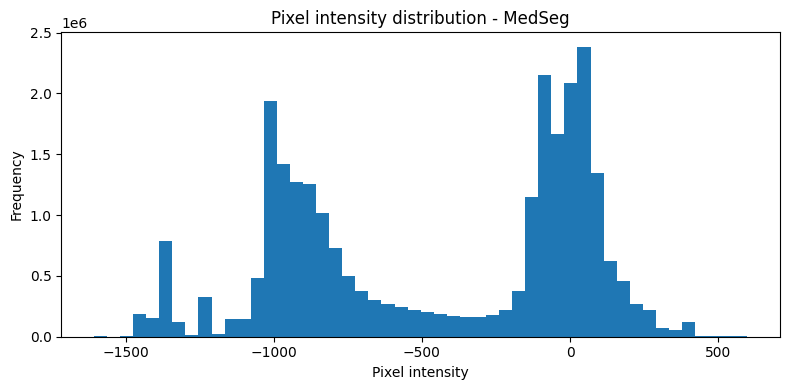

Minimum: -1606.522
Maximum: 597.805
Mean: -443.236
Std: 494.815


In [114]:
plot_intensity_distribution(data["images_medseg"], "MedSeg")

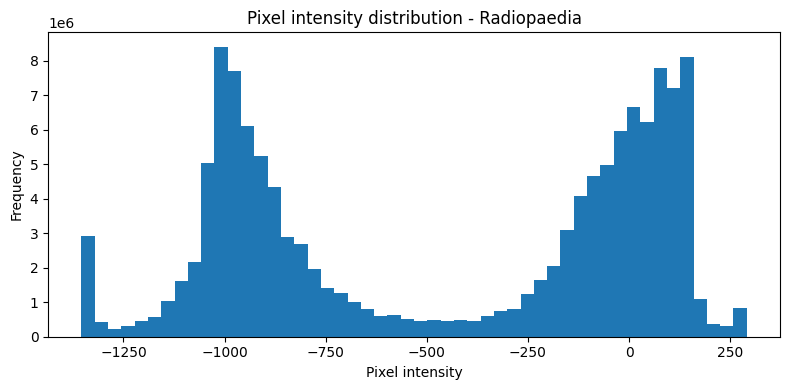

Minimum: -1353.959
Maximum: 291.041
Mean: -447.194
Std: 491.566


In [115]:
plot_intensity_distribution(data["images_radiopedia"], "Radiopaedia")

#### Distribución del Área Segmentada

In [116]:
def plot_lesion_area_distribution(masks):
    lesion_mask = masks[..., [0, 1]].any(axis=-1)

    total_area = masks.shape[1] * masks.shape[2]

    lesion_area = lesion_mask.sum(axis=(1, 2))
    lesion_percentage = lesion_area / total_area * 100

    plt.figure(figsize=(8, 4))
    plt.hist(lesion_percentage, bins=30)

    plt.xlabel("Lesion area (%)")
    plt.ylabel("Number of images")
    plt.title("Lesion area distribution")

    plt.tight_layout()
    plt.show()

    print(f"Mean: {lesion_percentage.mean():.2f}%")
    print(f"Median: {np.median(lesion_percentage):.2f}%")
    print(f"Std: {lesion_percentage.std():.2f}%")
    print(f"Maximum: {lesion_percentage.max():.2f}%")

    return lesion_percentage

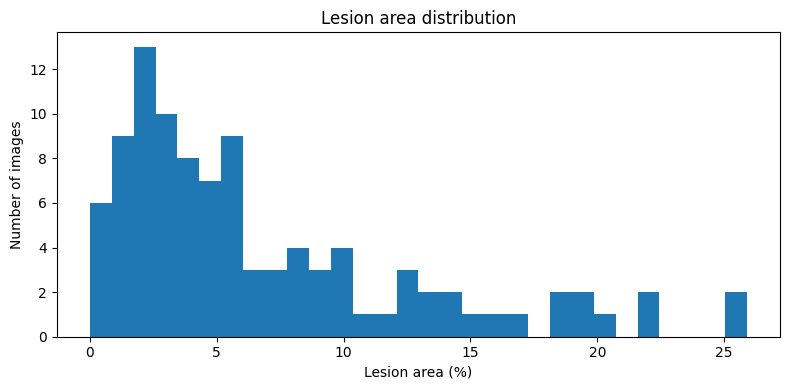

Mean: 6.81%
Median: 4.73%
Std: 6.05%
Maximum: 25.90%


In [117]:
medseg_lesion_area = plot_lesion_area_distribution(data["masks_medseg"])

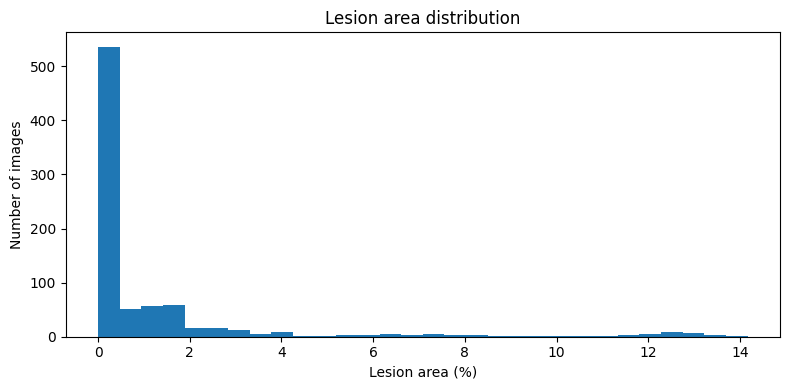

Mean: 1.25%
Median: 0.00%
Std: 2.75%
Maximum: 14.17%


In [118]:
radiopedia_lesion_area = plot_lesion_area_distribution(data["masks_radiopedia"])

#### Componentes Conectados

In [119]:
def count_lesion_components(masks):
    lesion_mask = masks[..., [0, 1]].any(axis=-1)

    counts = []

    for image_mask in lesion_mask:
        _, n_components = ndimage.label(image_mask)
        counts.append(n_components)

    counts = np.array(counts)

    print(f"Mean components: {counts.mean():.2f}")
    print(f"Median components: {np.median(counts):.2f}")
    print(f"Maximum components: {counts.max()}")

    return counts

In [120]:
medseg_components = count_lesion_components(data["masks_medseg"])

Mean components: 8.06
Median components: 7.00
Maximum components: 34


In [121]:
radiopedia_components = count_lesion_components(data["masks_radiopedia"])

Mean components: 1.92
Median components: 0.00
Maximum components: 21


### 2.3 Preprocesamiento de Datos

#### División de Datos

In [122]:
def data_split(images, masks, train_ratio=0.7, val_ratio=0.15, seed=42):
    n = len(images)

    rng = np.random.default_rng(seed)
    indices = rng.permutation(n)

    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train_indices = indices[:n_train]
    val_indices = indices[n_train:n_train + n_val]
    test_indices = indices[n_train + n_val:]

    train_images = images[train_indices]
    train_masks = masks[train_indices]

    val_images = images[val_indices]
    val_masks = masks[val_indices]

    test_images = images[test_indices]
    test_masks = masks[test_indices]

    return (
        train_images,
        train_masks,
        val_images,
        val_masks,
        test_images,
        test_masks
    )

In [123]:
(
    train_images,
    train_masks,
    val_images,
    val_masks,
    test_images,
    test_masks
) = data_split(
    data["images_medseg"],
    data["masks_medseg"],
    train_ratio=0.7,
    val_ratio=0.15,
    seed=42
)

competition_test_images = data["test_images_medseg"]

print(f"Train: {len(train_images)}")
print(f"Validation: {len(val_images)}")
print(f"Test interno: {len(test_images)}")
print(f"Competition test: {len(competition_test_images)}")

Train: 70
Validation: 15
Test interno: 15
Competition test: 10


In [124]:
# Añadir Radiopaedia SOLO al entrenamiento

radiopedia_images = data["images_radiopedia"]
radiopedia_masks = data["masks_radiopedia"]

train_images = np.concatenate([
    train_images,
    radiopedia_images
], axis=0)

train_masks = np.concatenate([
    train_masks,
    radiopedia_masks
], axis=0)

print("\nDespués de añadir Radiopaedia:")
print("Train images:", train_images.shape)
print("Train masks:", train_masks.shape)
print("Validation images:", val_images.shape)
print("Test images:", test_images.shape)


Después de añadir Radiopaedia:
Train images: (899, 512, 512, 1)
Train masks: (899, 512, 512, 4)
Validation images: (15, 512, 512, 1)
Test images: (15, 512, 512, 1)


#### Comparación de Conjuntos

In [125]:
target_class_names = ["Ground glass", "Consolidations"]

def compare_class_distribution(train_masks, val_masks, test_masks):
    datasets = {
        "Train": train_masks,
        "Validation": val_masks,
        "Test": test_masks
    }

    results = {}

    for name, masks in datasets.items():
        pixel_counts = masks[..., [0, 1]].sum(axis=(0, 1, 2))
        total_target_pixels = pixel_counts.sum()

        proportions = pixel_counts / total_target_pixels

        results[name] = proportions

        print(f"\n{name}")
        for class_name, proportion in zip(target_class_names, proportions):
            print(f"{class_name}: {proportion:.4%}")

    return results

In [126]:
class_distribution = compare_class_distribution(train_masks, val_masks, test_masks)


Train
Ground glass: 76.4262%
Consolidations: 23.5738%

Validation
Ground glass: 64.9306%
Consolidations: 35.0694%

Test
Ground glass: 77.7202%
Consolidations: 22.2798%


In [127]:
def compare_lesion_presence(train_masks, val_masks, test_masks):
    datasets = {
        "Train": train_masks,
        "Validation": val_masks,
        "Test": test_masks
    }

    for name, masks in datasets.items():
        lesion_mask = masks[..., [0, 1]].any(axis=-1)
        has_lesion = lesion_mask.any(axis=(1, 2))

        positive = has_lesion.sum()
        negative = len(has_lesion) - positive

        print(f"{name}: {positive} with lesions, {negative} without lesions")

In [128]:
compare_lesion_presence(train_masks, val_masks, test_masks)

Train: 441 with lesions, 458 without lesions
Validation: 15 with lesions, 0 without lesions
Test: 15 with lesions, 0 without lesions


#### Selección de Clases Objetivo

In [129]:
target_channels = [0, 1]

train_masks = train_masks[..., target_channels]
val_masks = val_masks[..., target_channels]
test_masks = test_masks[..., target_channels]

#### Transformación y Aumentación

In [130]:
train_mean = np.mean(train_images, axis=(0, 1, 2))
train_std = np.std(train_images, axis=(0, 1, 2))

In [131]:
class Transformer:
    def __init__(self, img_height, img_width, mean, std):
        self.img_height = img_height
        self.img_width = img_width
        self.mean = mean
        self.std = std

    def train(self):
        return A.Compose([
            A.Resize(height=self.img_height, width=self.img_width),
            A.Rotate(limit=35, p=1.0),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.1),
            A.Normalize(mean=self.mean, std=self.std, max_pixel_value=1.0),
            ToTensorV2()
        ])

    def validation(self):
        return A.Compose([
            A.Resize(height=self.img_height, width=self.img_width),
            A.Normalize(mean=self.mean, std=self.std, max_pixel_value=1.0),
            ToTensorV2()
        ])

In [132]:
transformer = Transformer(
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
    train_mean,
    train_std
)

train_transform = transformer.train()
val_transform = transformer.validation()

#### Dataset

In [133]:
class CovidDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image = self.images[index]
        mask = self.masks[index].astype(np.float32)

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)

            image = augmented["image"]
            mask = augmented["mask"]

        mask = mask.permute(2, 0, 1).float()

        return image, mask

In [134]:
train_dataset = CovidDataset(
    train_images,
    train_masks,
    transform=train_transform
)

val_dataset = CovidDataset(
    val_images,
    val_masks,
    transform=val_transform
)

test_dataset = CovidDataset(
    test_images,
    test_masks,
    transform=val_transform
)

In [135]:
competition_test_dataset = CovidDataset(
    competition_test_images,
    np.zeros(
        (*competition_test_images.shape[:3], NUM_CLASSES),
        dtype=np.float32
    ),
    transform=val_transform
)

#### Dataloader

In [136]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

In [137]:
competition_test_loader = DataLoader(
    competition_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

---

## 3. Modelo

In [138]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=NUM_CLASSES
)

---

## 4. Entrenamiento

#### Configuración del Entrenamiento

In [139]:
@dataclass
class TrainerConfig:
    learning_rate: float = 1e-4
    weight_decay: float = 1e-4
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    batch_size: int = 32
    num_epochs: int = 100
    num_workers: int = 2
    image_height: int = 160
    image_width: int = 240
    pin_memory: bool = True
    patience: int = 10

#### Función de Pérdida

In [140]:
class BCEDiceLoss(nn.Module):

    def __init__(self, smooth=1.0):
        super().__init__()

        self.bce = nn.BCEWithLogitsLoss()
        self.smooth = smooth

    def forward(self, predictions, targets):
        targets = targets.float()
        bce = self.bce(predictions, targets)
        probs = torch.sigmoid(predictions)
        dims = (0, 2, 3)
        intersection = (probs * targets).sum(dims)
        denominator = (probs.sum(dims) + targets.sum(dims))
        dice = (2 * intersection + self.smooth) / (denominator + self.smooth)
        dice_loss = 1 - dice.mean()

        return bce + dice_loss

#### Optimizador

In [141]:
config = TrainerConfig()
model = model.to(config.device)
loss_fn = BCEDiceLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=config.weight_decay
)

#### Escalador

In [142]:
scaler = torch.amp.GradScaler("cuda")

#### Clase de Entrenamiento del Modelo

In [143]:
class Trainer:
    def __init__(self, train_loader, val_loader, model, optimizer, loss_fn, scaler, config):
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.model = model
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.scaler = scaler
        self.config = config
        self.best_val_loss = float("inf")
        self.epochs_without_improvement = 0
        self.train_losses = []
        self.val_losses = []

    def __call__(self):
        for epoch in range(1, self.config.num_epochs + 1):
            train_loss = self.run_epoch(self.train_loader, training=True)
            val_loss = self.run_epoch(self.val_loader, training=False)

            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)

            print(
                f"Epoch [{epoch}/{self.config.num_epochs}] "
                f"Train Loss: {train_loss:.4f} "
                f"Val Loss: {val_loss:.4f}"
            )

            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.epochs_without_improvement = 0

                torch.save(self.model.state_dict(), "best_model.pth")
                print("Best model saved!")

            else:
                self.epochs_without_improvement += 1

                print(f"No improvement for {self.epochs_without_improvement} epoch(s)")
                if self.epochs_without_improvement >= self.config.patience:
                    print("Early stopping!")
                    break

    def run_epoch(self, data_loader, training):
        if training:
            self.model.train()
        else:
            self.model.eval()

        running_loss = 0.0
        context = (torch.enable_grad() if training else torch.no_grad())
        loop = tqdm(data_loader, leave=True)

        with context:
            for data, targets in loop:
                data = data.to(self.config.device)
                targets = targets.to(self.config.device)

                with torch.amp.autocast(device_type="cuda", enabled=self.config.device == "cuda"):
                    predictions = self.model(data)
                    loss = self.loss_fn(predictions, targets)

                if training:
                    self.optimizer.zero_grad()
                    self.scaler.scale(loss).backward()
                    self.scaler.step(self.optimizer)
                    self.scaler.update()

                running_loss += loss.item()
                loop.set_postfix(loss=loss.item())

        return running_loss / len(data_loader)

#### Experimentación y Ajuste de Hiperparámetros

In [144]:
experiments = [
    {"learning_rate": 1e-3, "batch_size": 32, "weight_decay": 0},
    {"learning_rate": 1e-4, "batch_size": 32, "weight_decay": 0},
    {"learning_rate": 1e-5, "batch_size": 32, "weight_decay": 0},
    {"learning_rate": 1e-4, "batch_size": 16, "weight_decay": 0},
    {"learning_rate": 1e-4, "batch_size": 64, "weight_decay": 0},
    {"learning_rate": 1e-4, "batch_size": 32, "weight_decay": 1e-4},
    {"learning_rate": 1e-4, "batch_size": 32, "weight_decay": 1e-3},
]

In [145]:
results = []

if RUN_HYPERPARAMETER_SEARCH:
  for i, exp in enumerate(experiments):

      print("=" * 60)
      print(f"EXPERIMENT {i + 1}")
      print(exp)
      print("=" * 60)

      config = TrainerConfig(
          learning_rate=exp["learning_rate"],
          batch_size=exp["batch_size"],
          weight_decay=exp["weight_decay"],
          num_epochs=100,
          patience=5
      )

      train_loader = DataLoader(
          train_dataset,
          batch_size=config.batch_size,
          shuffle=True,
          num_workers=config.num_workers,
          pin_memory=config.pin_memory
      )

      val_loader = DataLoader(
          val_dataset,
          batch_size=config.batch_size,
          shuffle=False,
          num_workers=config.num_workers,
          pin_memory=config.pin_memory
      )

      model = smp.Unet(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=1,
        classes=NUM_CLASSES
      )

      model = model.to(config.device)

      optimizer = optim.Adam(
          model.parameters(),
          lr=config.learning_rate,
          weight_decay=config.weight_decay
      )

      scaler = torch.amp.GradScaler("cuda")

      trainer_exp = Trainer(
          train_loader=train_loader,
          val_loader=val_loader,
          model=model,
          optimizer=optimizer,
          loss_fn=loss_fn,
          scaler=scaler,
          config=config
      )

      trainer_exp()

      results.append({
          "experiment": i + 1,
          "learning_rate": config.learning_rate,
          "batch_size": config.batch_size,
          "weight_decay": config.weight_decay,
          "best_val_loss": trainer_exp.best_val_loss
      })


In [146]:
if RUN_HYPERPARAMETER_SEARCH:
  results_df = pd.DataFrame(results)

  results_df = results_df.sort_values(
      "best_val_loss"
  ).reset_index(drop=True)

  results_df

#### Ejecución del Entrenamiento Final

In [147]:
trainer = Trainer(
    train_loader=train_loader,
    val_loader=val_loader,
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    scaler=scaler,
    config=config
)

trainer()

100%|██████████| 1/1 [00:00<00:00,  1.44it/s, loss=1.75]


Epoch [1/100] Train Loss: 1.7267 Val Loss: 1.7488
Best model saved!


100%|██████████| 1/1 [00:00<00:00,  2.00it/s, loss=1.47]


Epoch [2/100] Train Loss: 1.5255 Val Loss: 1.4716
Best model saved!


100%|██████████| 1/1 [00:00<00:00,  3.46it/s, loss=1.41]


...

Epoch [57/100] Train Loss: 0.2678 Val Loss: 0.4497
No improvement for 8 epoch(s)


100%|██████████| 1/1 [00:00<00:00,  2.29it/s, loss=0.456]


Epoch [58/100] Train Loss: 0.2442 Val Loss: 0.4562
No improvement for 9 epoch(s)


100%|██████████| 1/1 [00:00<00:00,  3.44it/s, loss=0.452]

Epoch [59/100] Train Loss: 0.2509 Val Loss: 0.4524
No improvement for 10 epoch(s)
Early stopping!


---

## 5. Resultados

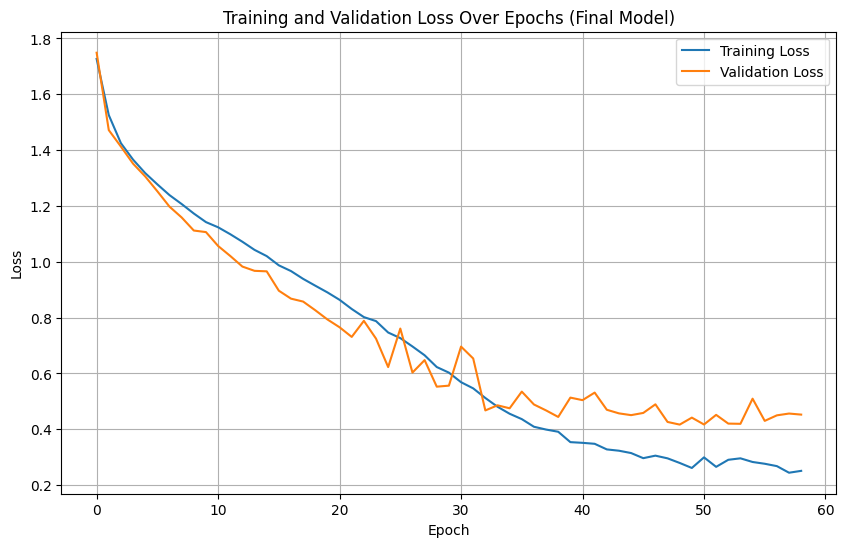

In [163]:
plt.figure(figsize=(10, 6))
plt.plot(trainer.train_losses, label='Training Loss')
plt.plot(trainer.val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs (Final Model)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [164]:
def calculate_metrics(predictions, targets, threshold=0.5):
    predictions = torch.sigmoid(predictions)
    predictions = (predictions > threshold).float()
    targets = targets.float()

    dims = (0, 2, 3)
    intersection = (predictions * targets).sum(dims)
    prediction_area = predictions.sum(dims)
    target_area = targets.sum(dims)
    union = prediction_area + target_area - intersection

    dice = (2 * intersection + 1e-7) / (prediction_area + target_area + 1e-7)
    iou = (intersection + 1e-7) / (union + 1e-7)
    precision = (intersection + 1e-7) / (prediction_area + 1e-7)
    recall = (intersection + 1e-7) / (target_area + 1e-7)
    f1 = (2 * precision * recall) / (precision + recall + 1e-7)

    return dice, iou, f1

In [165]:
model.load_state_dict(
    torch.load("best_model.pth", map_location=DEVICE)
)

_ = model.eval()

In [166]:
def evaluate_model(model, data_loader, device, threshold=0.5):
    model.eval()

    intersection = torch.zeros(NUM_CLASSES, device=device)
    prediction_sum = torch.zeros(NUM_CLASSES, device=device)
    target_sum = torch.zeros(NUM_CLASSES, device=device)

    with torch.no_grad():
        for images, targets in tqdm(data_loader):
            images = images.to(device)
            targets = targets.to(device)

            logits = model(images)

            probabilities = torch.sigmoid(logits)
            predictions = (probabilities > threshold).float()
            dims = (0, 2, 3)

            intersection += (predictions * targets).sum(dim=dims)
            prediction_sum += predictions.sum(dim=dims)
            target_sum += targets.sum(dim=dims)

    epsilon = 1e-7

    dice = (2 * intersection + epsilon) / (prediction_sum + target_sum + epsilon)
    union = (prediction_sum + target_sum - intersection)
    iou = (intersection + epsilon) / (union + epsilon)
    f1 = dice.clone()

    return dice.cpu(), iou.cpu(), f1.cpu()

In [167]:
thresholds = np.arange(0.30, 0.71, 0.01)
threshold_results = []

for threshold in thresholds:

    dice, iou, f1 = evaluate_model(
        model,
        val_loader,
        DEVICE,
        threshold=threshold
    )

    threshold_results.append({
        "threshold": threshold,
        "f1": f1.mean().item()
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

100%|██████████| 1/1 [00:00<00:00,  3.75it/s]


,threshold,f1
0,0.30,0.679732
1,0.31,0.679859
2,0.32,0.679664
3,0.33,0.679842
4,0.34,0.679519
5,0.35,0.679313
6,0.36,0.679015
7,0.37,0.678834
8,0.38,0.678590
9,0.39,0.678324


In [168]:
best_threshold = threshold_df.loc[
    threshold_df["f1"].idxmax(),
    "threshold"
]

print("Best threshold:", best_threshold)

Best threshold: 0.31


In [169]:
test_dice, test_iou, test_f1 = evaluate_model(model, test_loader, DEVICE, best_threshold)

for i, class_name in enumerate(target_class_names):
    print(f"\n{class_name}")
    print(f"Dice: {test_dice[i]:.4f}")
    print(f"IoU:  {test_iou[i]:.4f}")
    print(f"F1:   {test_f1[i]:.4f}")

print("\nAverage")
print(f"Dice: {test_dice.mean():.4f}")
print(f"IoU:  {test_iou.mean():.4f}")
print(f"F1:   {test_f1.mean():.4f}")

100%|██████████| 1/1 [00:00<00:00,  3.68it/s]


Ground glass
Dice: 0.7707
IoU:  0.6269
F1:   0.7707

Consolidations
Dice: 0.5821
IoU:  0.4106
F1:   0.5821

Average
Dice: 0.6764
IoU:  0.5187
F1:   0.6764


In [170]:
def show_predictions(model, dataset, device, num_samples=5, threshold=0.5):

    model.eval()
    fig, axes = plt.subplots(5, num_samples, figsize=(num_samples * 3, 15))

    for i in range(num_samples):

        image, target = dataset[i]

        with torch.no_grad():
            logits = model(image.unsqueeze(0).to(device))

        prediction = torch.sigmoid(logits)[0].cpu()
        prediction = prediction > threshold

        axes[0, i].imshow(image.squeeze(), cmap="gray")
        axes[1, i].imshow(target[0], cmap="gray")
        axes[2, i].imshow(prediction[0], cmap="gray")
        axes[3, i].imshow(target[1], cmap="gray")
        axes[4, i].imshow(prediction[1], cmap="gray")

        axes[0, i].set_title("CT")
        axes[1, i].set_title("GT Ground Glass")
        axes[2, i].set_title("Pred Ground Glass")
        axes[3, i].set_title("GT Consolidation")
        axes[4, i].set_title("Pred Consolidation")

        for row in range(5):
            axes[row, i].axis("off")

    plt.tight_layout()
    plt.show()

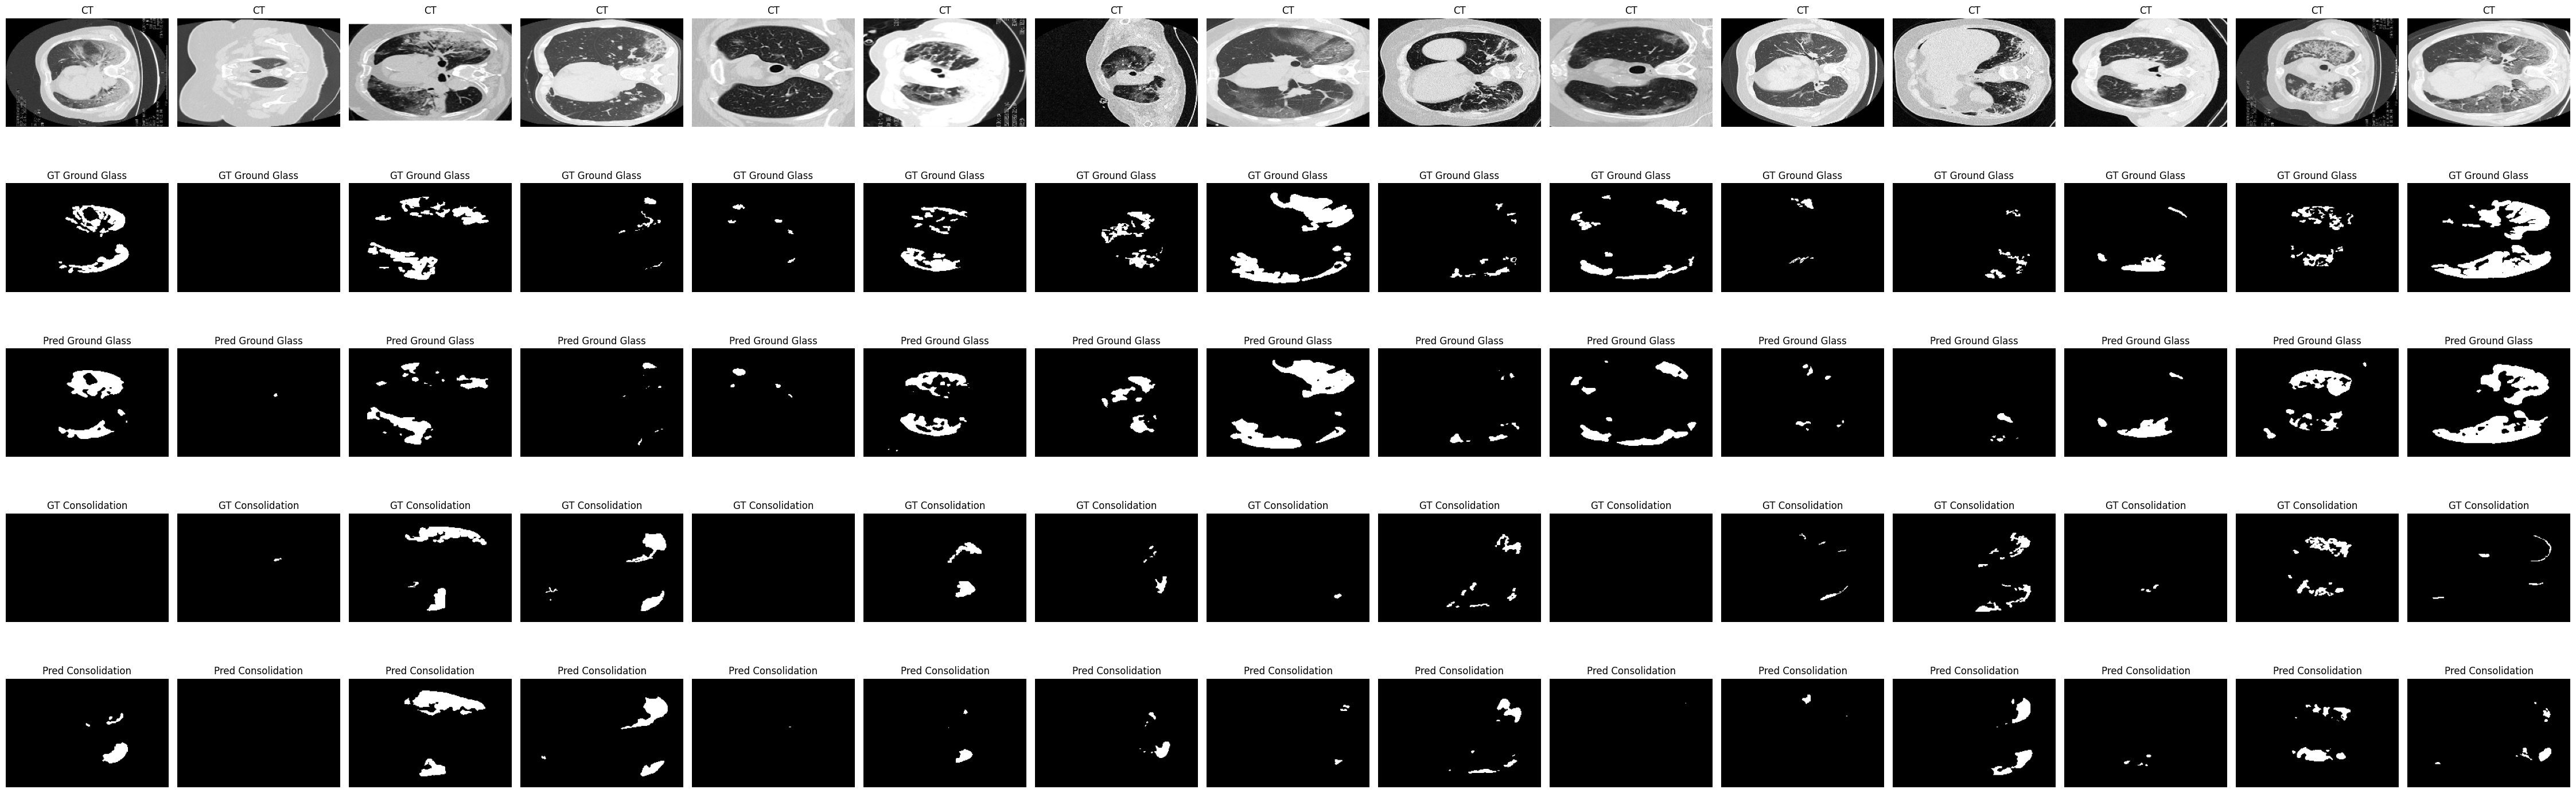

In [156]:
show_predictions(model, test_dataset, DEVICE, num_samples=15, threshold=best_threshold)

## Generación del Submission para Kaggle

#### Predicción sobre la Prueba de la Competición

In [171]:
competition_predictions = []

model.eval()

with torch.no_grad():
    for images, _ in tqdm(competition_test_loader):
        images = images.to(DEVICE)

        logits = model(images)
        probabilities = torch.sigmoid(logits)

        competition_predictions.append(probabilities.cpu())

competition_predictions = torch.cat(competition_predictions, dim=0)

print("Prediction shape:", competition_predictions.shape)

100%|██████████| 1/1 [00:00<00:00,  3.66it/s]

Prediction shape: torch.Size([10, 2, 160, 240])


#### Restauración de las Dimensiones Originales

In [172]:
competition_predictions = F.interpolate(
    competition_predictions,
    size=(512, 512),
    mode="bilinear",
    align_corners=False
)

print("Resized prediction shape:", competition_predictions.shape)

Resized prediction shape: torch.Size([10, 2, 512, 512])


In [173]:
competition_masks = (
    competition_predictions > best_threshold
).int()

print("Threshold:", best_threshold)
print("Mask shape:", competition_masks.shape)

Threshold: 0.31
Mask shape: torch.Size([10, 2, 512, 512])


#### Aplicación del Umbral Seleccionado

In [174]:
test_masks_prediction = (
    competition_masks
    .permute(0, 2, 3, 1)
    .numpy()
)

print("Final prediction shape:", test_masks_prediction.shape)

Final prediction shape: (10, 512, 512, 2)


#### Creación del Archivo de Entrega

In [175]:
submission = pd.DataFrame(
    data=np.stack(
        (
            np.arange(len(test_masks_prediction.ravel())),
            test_masks_prediction.ravel().astype(int)
        ),
        axis=-1
    ),
    columns=["Id", "Predicted"]
)

submission = submission.set_index("Id")
submission.to_csv("submission.csv")

#### Verificación de la Entrega

In [177]:
print("Submission shape:", submission.shape)

print("\nClass distribution:")
print(submission["Predicted"].value_counts())

print("\nFirst rows:")
display(submission.head())

Submission shape: (5242880, 1)

Class distribution:
Predicted
0    5097221
1     145659
Name: count, dtype: int64

First rows:


,Predicted
Id,
0,0
1,0
2,0
3,0
4,0
